In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
SEED = 42
import random
random.seed(SEED)
import torch
torch.manual_seed(SEED)

import librosa
from matplotlib import pyplot as plt

from modules.datamodule import LungSoundDataModule
from modules.transforms import *

# NOTE: Some classes have very few samples, so we will focus on a subset of classes for the analysis.
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "COPD",
    "Healthy",
    "Lung Fibrosis",
    "Pneumonia",
    "URTI",
]

TARGET_SR = 44100   # Hz
WINDOW_LENGTH = 6   # seconds
HOP_LENGTH = 6      # seconds

transformations = Compose([
    Spectrogram(),
])
  
config = {
    "batch_size": 16,
    "num_workers": 4,
    "seed": SEED,
    "dataset": {
        "name": "combined",
        "classes": SELECTED_CLASSES,
    },
    "sampler": None,
    "transforms": {
        "train": transformations,
        "val": transformations,
        "test": transformations,
    }
}

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/preprocessed")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

In [6]:
def visualize_batch(datamodule: LungSoundDataModule, class_names: list):
    """ Visualize a batch of samples from the dataloader. """
    dataloader = datamodule.train_dataloader()
    batch_samples, batch_labels = next(iter(dataloader))
    num_rows = len(batch_samples) // 4
    num_cols = len(batch_samples) // num_rows
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    axes = axes.flatten()
    for i in range(len(batch_samples)):
        sample = batch_samples[i]
        label = batch_labels[i]
        class_name = class_names[label.item()]
        np_sample = sample.cpu().numpy().squeeze()
        librosa.display.specshow(np_sample, sr=TARGET_SR, ax=axes[i])
        axes[i].set_title(f"{class_name} (Label: {label.item()})")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

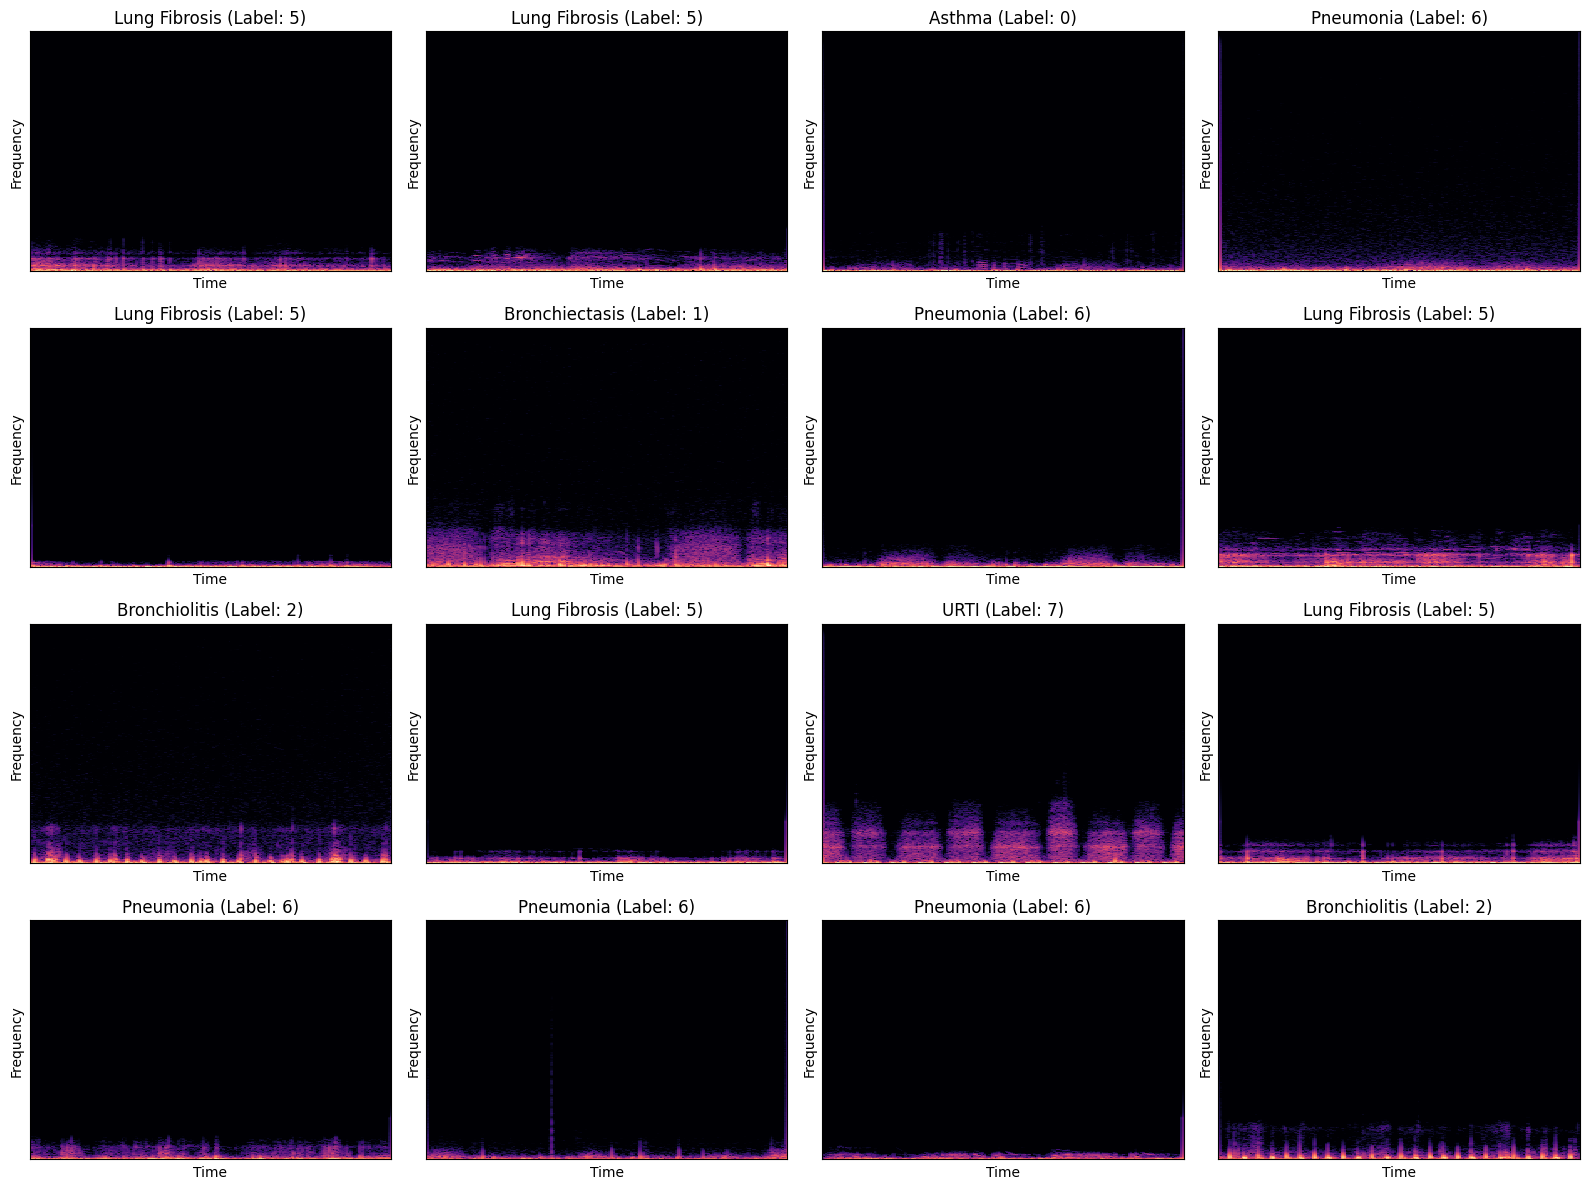

In [7]:
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)

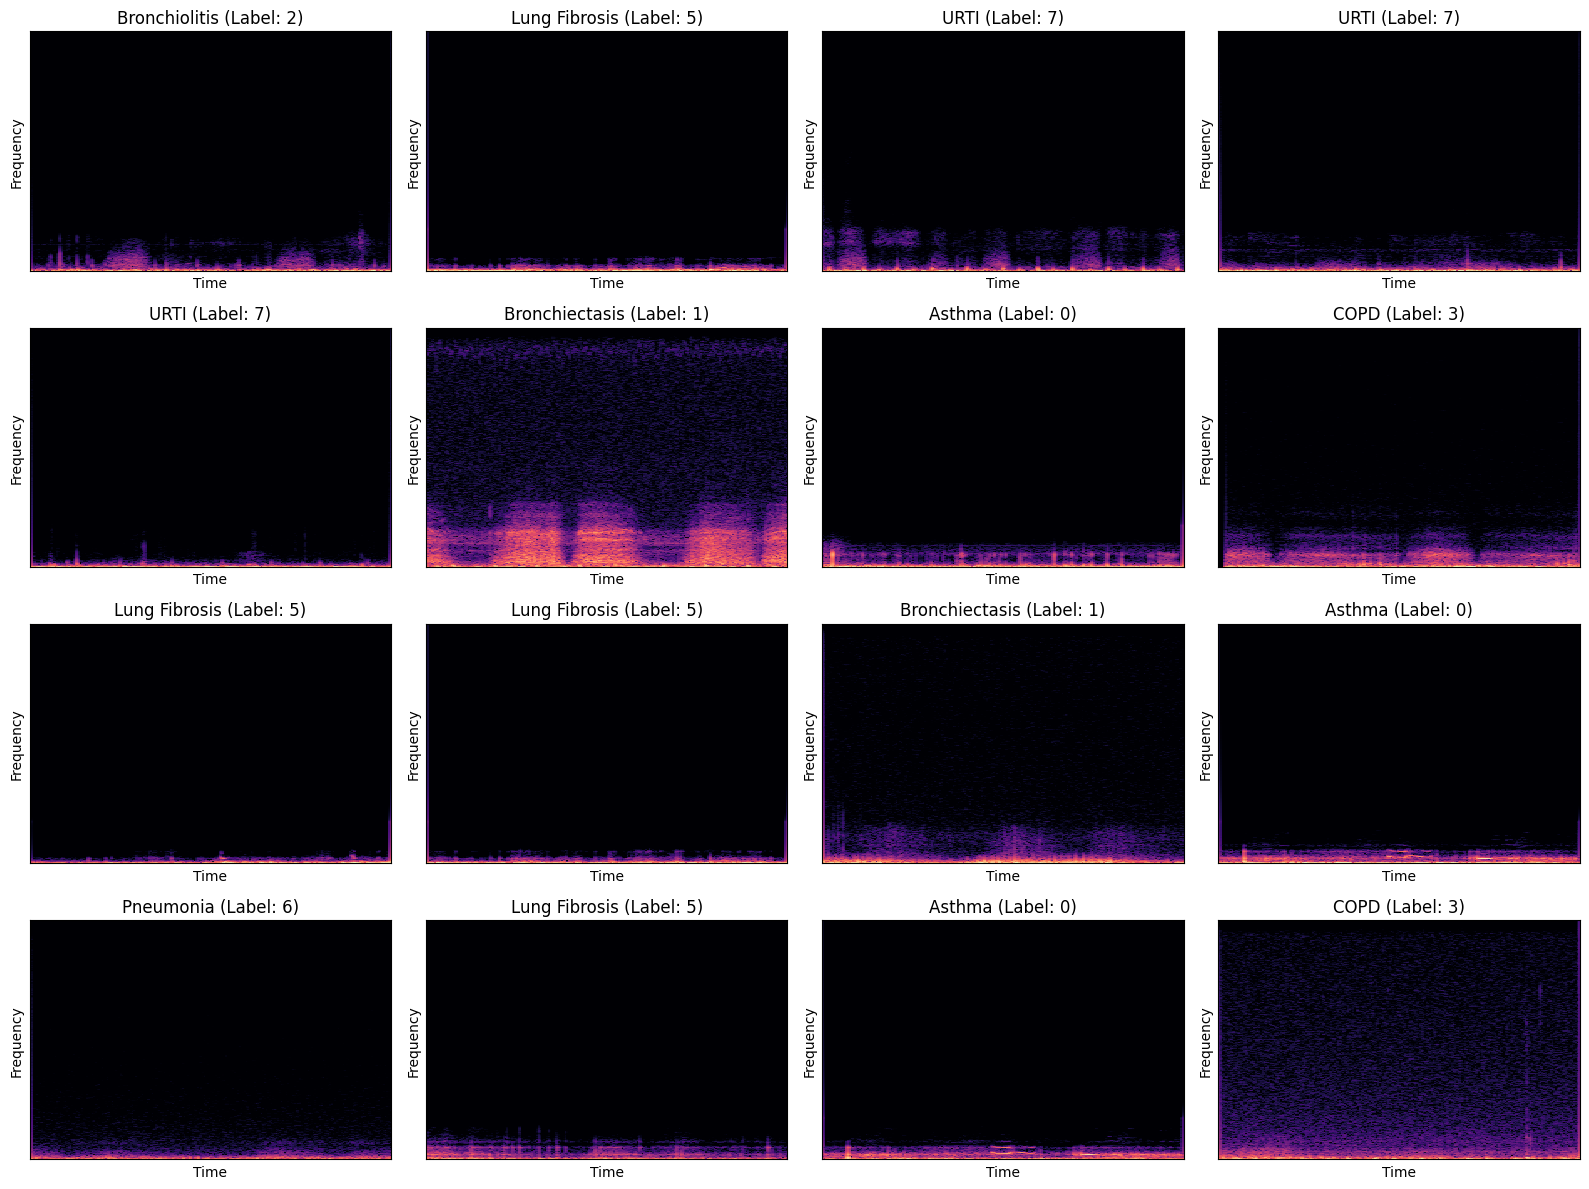

In [8]:
config["sampler"] = "equalizer"
dm = LungSoundDataModule(config, DATA_FOLDER)
dm.setup()
visualize_batch(dm, SELECTED_CLASSES)